<a href="https://colab.research.google.com/github/izzat-ai/learning-ai/blob/main/data_visualization/seaborn/visualization_with_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Ushbu sahifada seaborn bilan vizualizatsiya qilamiz .
- Ma'lumotlar real ma'lumotlarga asoslangan bo'ladi va uni AI yaratib beradi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
# Tasodifiy sonlar bir xil chiqishi uchun seed o'rnatamiz
np.random.seed(42)

n_employees = 150


# Kompaniya xodimlarining oylik maoshlari va samaradorligi haqidagi dataset

data = {
    "Xodim_ID": range(1001, 1001 + n_employees),
    "Departament": np.random.choice(
        ["IT", "HR", "Marketing", "Sales"], n_employees, p=[0.3, 0.15, 0.25, 0.3]
    ),
    "Tajriba_Yil": np.random.randint(1, 11, n_employees),
    "Masofadan_Ishlash": np.random.choice(["Ha", "Yo'q"], n_employees, p=[0.4, 0.6]),
    "Samaradorlik_Bali": np.random.randint(50, 101, n_employees),
}

df = pd.DataFrame(data)

# Maoshni tajriba va departamentga bog'lab, biroz realistik qilamiz
base_salary = df["Tajriba_Yil"] * 800 + df["Samaradorlik_Bali"] * 50
dept_bonus = df["Departament"].map(
    {"IT": 3000, "HR": 1000, "Marketing": 1500, "Sales": 2000}
)
df["Maosh_USD"] = (
    base_salary + dept_bonus + np.random.normal(0, 500, n_employees)
).astype(int)

df

,Xodim_ID,Departament,Tajriba_Yil,Masofadan_Ishlash,Samaradorlik_Bali,Maosh_USD
0,1001,HR,1,Ha,85,5193
1,1002,Sales,1,Yo'q,72,7076
2,1003,Sales,3,Yo'q,65,7592
3,1004,Marketing,2,Yo'q,88,8118
4,1005,IT,5,Yo'q,94,10902
...,...,...,...,...,...,...
145,1146,IT,8,Yo'q,94,13535
146,1147,Marketing,1,Yo'q,54,5264
147,1148,Marketing,9,Ha,82,13520
148,1149,IT,6,Ha,50,9064


In [3]:
# qanday soha vakillari borligini aniqlash
df['Departament'].value_counts()

,count
Departament,
IT,51
Sales,45
Marketing,30
HR,24


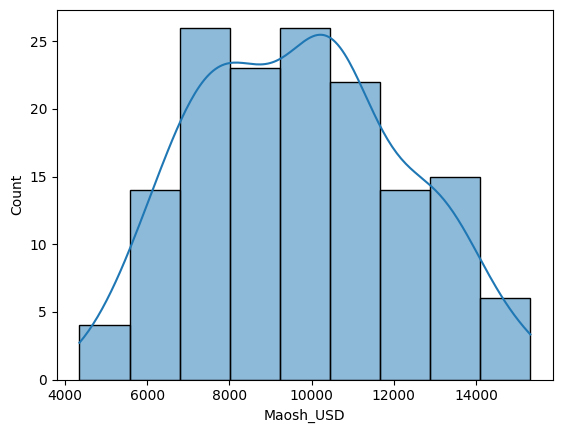

In [4]:
sns.histplot(df['Maosh_USD'], kde=True)
sns.set_theme(style="whitegrid")
plt.show()

- kampaniyadagi maoshlar 4500 dan boshlanib , 15000 gacha boradi
- ko'p xodimlar 7000-8000 va 10000-11500 atrofida oylik olishadi . Buni KDE ya'ni ko'k silliq chiziqdan ham bilsak bo'ladi
- 5500 dan kam va 14000 dan ko'p maosh oladigan hodimlar judayam kam

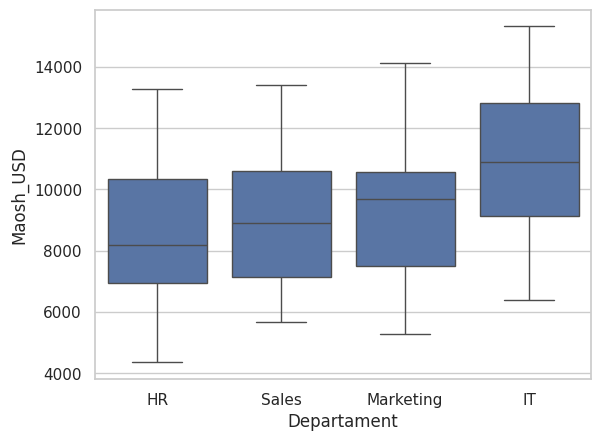

In [5]:
sns.boxplot(data=df, x='Departament', y='Maosh_USD')
sns.set_theme(style="whitegrid")
plt.show()

- kampaniyada eng yuqori maoshni IT sohasi hodimlari olishadi . Uning mediani (o'rta maoshi) ham qolgan departamentlaridan yuqorida ekani yaqqol ko'rinyapti (o'rtadagi qora chiziq) . Shu bilan birga 15000 aqsh dollaridan ko'p maosh oladiganlar ham mana shu soha vakillari hisoblanadi
- o'rta maoshi va eng kam maosh oladigan departament bu HR . HR vakillarini o'rta maoshi qolgan departamentlarnikidan sezirarli darajada past
- Marketingda esa yuqori va past maosh oladigan hodimlar ko'p

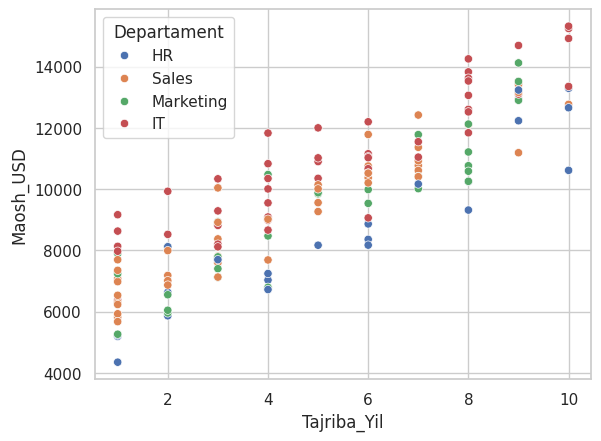

In [6]:
sns.scatterplot(data=df, x='Tajriba_Yil', y='Maosh_USD', hue='Departament')
plt.show()

- ushbu grafikdan barcha soha vakillarini tajribasi ortgani sari ularning maoshlari ham o'sib borganini ko'rishimiz mumkin
- yuqorida aytganimizdek , tajribasidan qancha ekanligidan qat'iy nazar eng ko'p maoshni IT sohasi egalari olishini ushbu grafikdan ham ko'rsak bo'ladi (qizil nuqtalar)
- eng kam maosh esa HR vakillariniki hisoblanadi

In [7]:
df.head()

,Xodim_ID,Departament,Tajriba_Yil,Masofadan_Ishlash,Samaradorlik_Bali,Maosh_USD
0,1001,HR,1,Ha,85,5193
1,1002,Sales,1,Yo'q,72,7076
2,1003,Sales,3,Yo'q,65,7592
3,1004,Marketing,2,Yo'q,88,8118
4,1005,IT,5,Yo'q,94,10902


In [8]:
# sonli ustunlarni bog'liqligini aniqlash
df_num_corr = df.drop(columns=['Xodim_ID']).corr(numeric_only=True)
df_num_corr

,Tajriba_Yil,Samaradorlik_Bali,Maosh_USD
Tajriba_Yil,1.000000,-0.094663,0.879857
Samaradorlik_Bali,-0.094663,1.000000,0.208476
Maosh_USD,0.879857,0.208476,1.000000


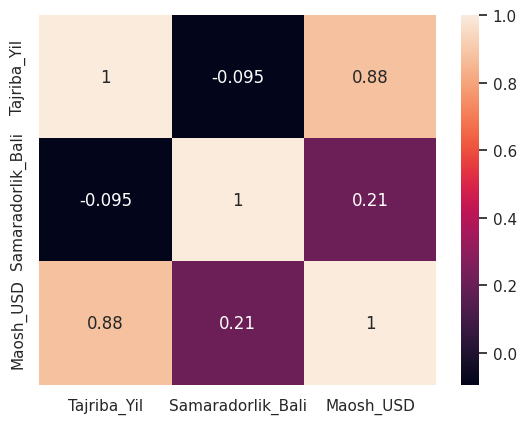

In [9]:
sns.heatmap(df_num_corr, annot=True)
plt.show()

- tajriba va maosh ustunlari orasida juda kuchliy ijobiy bog'liqlik bor va bu 0.88 ni tashkil qilgan . Yuqorida scatterplotda ko'rganimizdek , tajriba oshgani sari maosh ham o'sib boradi
- tajriba va samaradorlikda esa hech qanday bog'liqlik yo'q va deyarli 0 ga teng . Kampaniyada yillardan buyon tajribasi ko'p hodimlar har doim ham yaxshi natija bermaydi . Aksincha yangi kelgan hodim ham kampaniyada yaxshi natija ko'rsatishi mumkin
- maoshning oshishiga samaradorlik deyarli ta'sir ko'rsatmaydi

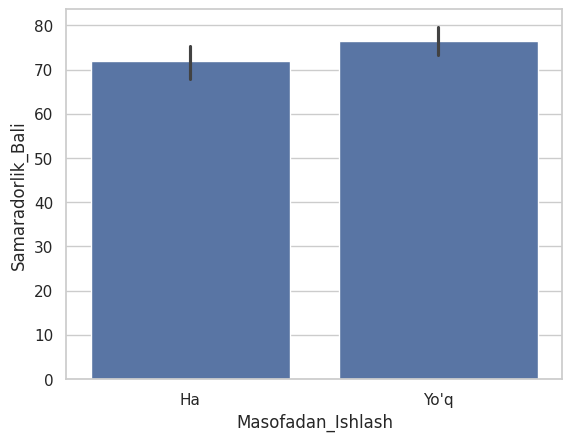

In [10]:
sns.barplot(data=df, x='Masofadan_Ishlash', y='Samaradorlik_Bali')
plt.show()

- kampaniyaga kelib ishlovchi hodimlar va masofadan ishlovchi hodimlar o'rtasida juda katta farq yo'q . Faqatgina doimiy kampaniyaga kelib ishlovchi hodimlarning o'rtacha samaradorligi yuqoriroq va tahminan 76 larni qayd etgan
- masofadan ishlovchi hodimlarning o'rtacha samaradorligi esa tahminan 71.5 larni tashkil qilgan

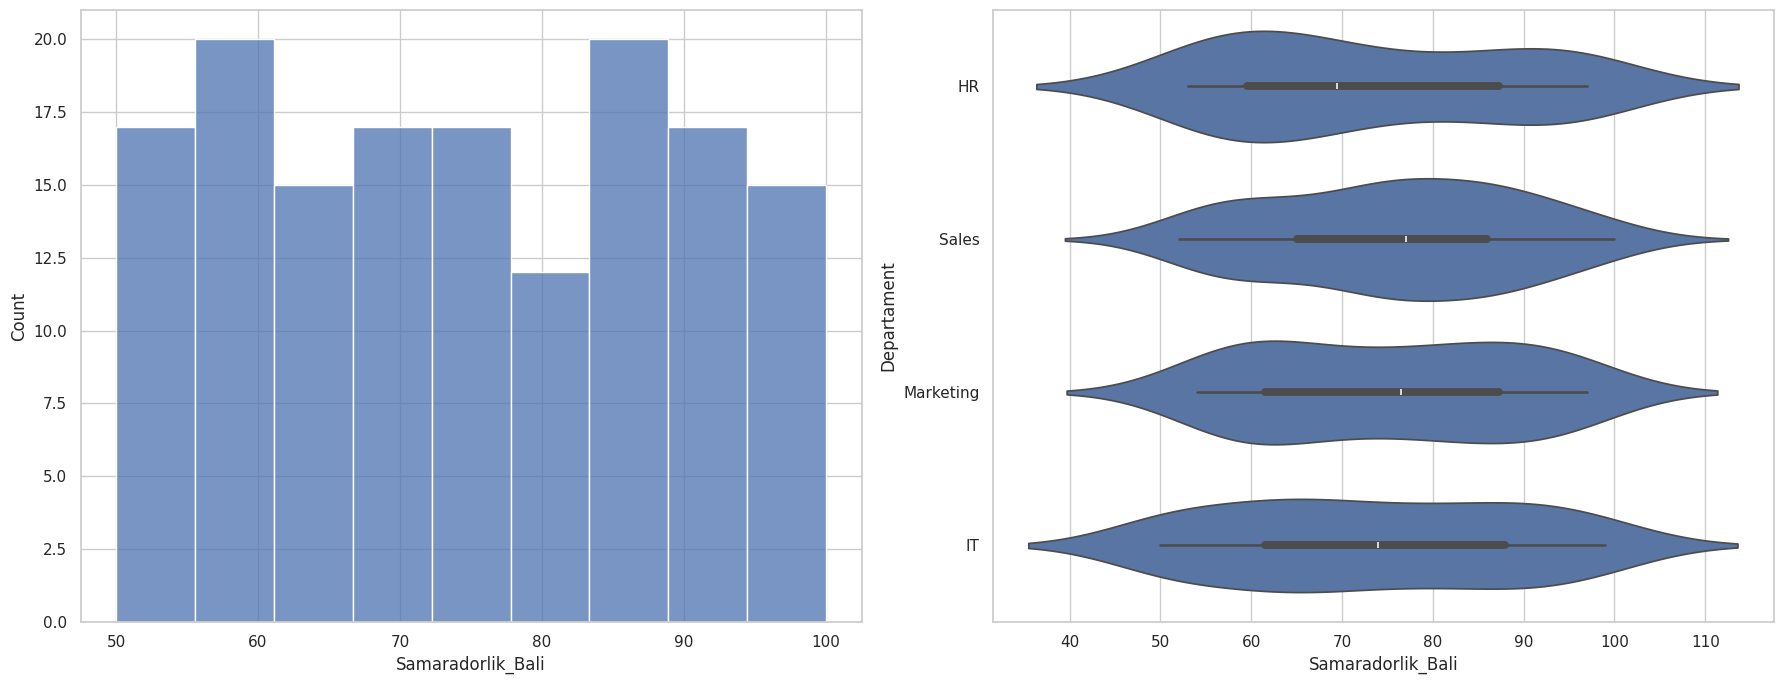

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
sns.histplot(df['Samaradorlik_Bali'], ax=ax[0])
sns.violinplot(data=df, x='Samaradorlik_Bali', y='Departament', ax=ax[1])

plt.tight_layout()
plt.show()

- chap tarafdagi grafikda Kampaniyadagi samaradorlik ballari keltirilgan . Unda yaqqol ajralib turadigan cho'qqi yo'q . Eng ko'p to'planish 55-60 va 85-90 ballik joylarda kuzatilgan
- o'ng tarafdagi grafikda , HR va Sales bo'limlaridagi xodimlarning asosiy qismi 65-70 va 85 ball atrofida to'plangan . Marketing esa o'rtacha olganda eng yuqori samaradorlikka ega bo'lib turibdi , chunki o'rtasidagi oq chiziq tahminan 77 larga to'g'ri kelmoqda . IT - 60 atrofida to'plangan va ularning umumiy samaradorligi boshqa bo'limlarga qaraganda pastroq